In [1]:
!pip install imbalanced-learn

In [30]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

In [34]:
from imblearn.over_sampling import SMOTE

In [48]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model

In [8]:
import numpy as np
import pandas as pd

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [28]:
DATA_PATH = "/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"

CLASS_NAMES = ["benign", "malignant", "normal"]

IMAGE_SIZE = 128

print(DATA_PATH)

/kaggle/input/datasets/sabahesaraki/breast-ultrasound-images-dataset/Dataset_BUSI_with_GT


In [31]:
def load_ultrasound_dataset(dataset_dir, categories, img_size):

    image_collection = []
    label_collection = []

    for category in categories:

        category_path = os.path.join(dataset_dir, category)

        for file_name in os.listdir(category_path):

            if "_mask" in file_name:
                continue

            file_path = os.path.join(category_path, file_name)

            img = cv2.imread(file_path)
            img = cv2.resize(img, (img_size, img_size))
            img = img.astype("float32") / 255.0

            image_collection.append(img)
            label_collection.append(category)

    images_np = np.array(image_collection)
    labels_np = np.array(label_collection)

    return images_np, labels_np


X, y = load_ultrasound_dataset(DATA_PATH, CLASS_NAMES, IMAGE_SIZE)

print("Dataset size:", X.shape)

Dataset size: (780, 128, 128, 3)


In [35]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded classes:", label_encoder.classes_)

Encoded classes: ['benign' 'malignant' 'normal']


In [36]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    stratify=y_encoded,
    random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Train: (546, 128, 128, 3)
Validation: (117, 128, 128, 3)
Test: (117, 128, 128, 3)


In [49]:
def build_transfer_model():

    backbone = MobileNetV2(
        input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
        include_top=False,
        weights="imagenet"
    )

    for layer in backbone.layers:
        layer.trainable = False

    x = backbone.output
    x = GlobalAveragePooling2D()(x)

    x = Dense(256, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)

    x = Dense(128, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)

    predictions = Dense(3, activation="softmax")(x)

    model = Model(inputs=backbone.input, outputs=predictions)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [50]:
imbalanced_model = build_transfer_model()

history_imbalanced = imbalanced_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=16
)

I0000 00:00:1773509329.762836      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/40


I0000 00:00:1773509337.763513     103 service.cc:152] XLA service 0x7fd418003950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1773509337.763547     103 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1773509338.897609     103 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1773509344.909231     103 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


35/35 ━━━━━━━━━━━━━━━━━━━━ 31s 513ms/step - accuracy: 0.3028 - loss: 1.7700 - val_accuracy: 0.3846 - val_loss: 1.1460
Epoch 2/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.4408 - loss: 1.3109 - val_accuracy: 0.4786 - val_loss: 1.0433
Epoch 3/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.4878 - loss: 1.2899 - val_accuracy: 0.5726 - val_loss: 0.9736
Epoch 4/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5411 - loss: 1.1003 - val_accuracy: 0.7009 - val_loss: 0.8378
Epoch 5/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5954 - loss: 0.9910 - val_accuracy: 0.6838 - val_loss: 0.7870
Epoch 6/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6219 - loss: 0.9753 - val_accuracy: 0.7009 - val_loss: 0.7143
Epoch 7/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6297 - loss: 0.8700 - val_accuracy: 0.7179 - val_loss: 0.6831
Epoch 8/40
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6601 - loss: 0.8459 - val_accuracy: 0.7265 - val_loss: 

## Evaluation Functions

In [51]:
def evaluate_model(model, X_test, y_test):

    preds = model.predict(X_test)
    pred_labels = np.argmax(preds, axis=1)

    acc = accuracy_score(y_test, pred_labels)
    prec = precision_score(y_test, pred_labels, average="weighted")
    rec = recall_score(y_test, pred_labels, average="weighted")
    f1 = f1_score(y_test, pred_labels, average="weighted")

    print("Accuracy:", acc)
    print("Precision:", prec)
    print("Recall:", rec)
    print("F1 Score:", f1)

    print("\nDetailed Report")
    print(classification_report(y_test, pred_labels))

    return acc, prec, rec, f1


print("Results for Imbalanced Training")
acc1, prec1, rec1, f11 = evaluate_model(imbalanced_model, X_test, y_test)

Results for Imbalanced Training
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step
Accuracy: 0.7008547008547008
Precision: 0.7325992190765687
Recall: 0.7008547008547008
F1 Score: 0.7083390358115633

Detailed Report
              precision    recall  f1-score   support

           0       0.85      0.70      0.77        66
           1       0.62      0.68      0.65        31
           2       0.52      0.75      0.61        20

    accuracy                           0.70       117
   macro avg       0.66      0.71      0.68       117
weighted avg       0.73      0.70      0.71       117



## Apply SMOTE for balancig data

In [52]:
X_train_vector = X_train.reshape(len(X_train), -1)

smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X_train_vector, y_train)

print("Before balancing:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_resampled))

X_resampled = X_resampled.reshape(-1, IMAGE_SIZE, IMAGE_SIZE, 3)

Before balancing: [306 147  93]
After SMOTE: [306 306 306]


In [53]:
balanced_model = build_transfer_model()

history_balanced = balanced_model.fit(
    X_resampled,
    y_resampled,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=16
)

print("Results for SMOTE Balanced Training")
acc2, prec2, rec2, f12 = evaluate_model(balanced_model, X_test, y_test)

Epoch 1/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 25s 265ms/step - accuracy: 0.4244 - loss: 1.4762 - val_accuracy: 0.6325 - val_loss: 0.8577
Epoch 2/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5876 - loss: 1.0364 - val_accuracy: 0.6496 - val_loss: 0.7727
Epoch 3/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6673 - loss: 0.8467 - val_accuracy: 0.6923 - val_loss: 0.7332
Epoch 4/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6879 - loss: 0.7693 - val_accuracy: 0.7094 - val_loss: 0.7033
Epoch 5/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7442 - loss: 0.6918 - val_accuracy: 0.7521 - val_loss: 0.6875
Epoch 6/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7574 - loss: 0.6154 - val_accuracy: 0.7350 - val_loss: 0.6984
Epoch 7/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7681 - loss: 0.5691 - val_accuracy: 0.7521 - val_loss: 0.6688
Epoch 8/40
58/58 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7569 - loss: 0.6020 - val_accuracy: 0.7350 - va

In [54]:
print("\nFinal Performance Comparison")

print("\nImbalanced Model")
print("Accuracy:", acc1)
print("Precision:", prec1)
print("Recall:", rec1)
print("F1 Score:", f11)

print("\nBalanced Model (SMOTE)")
print("Accuracy:", acc2)
print("Precision:", prec2)
print("Recall:", rec2)
print("F1 Score:", f12)


Final Performance Comparison

Imbalanced Model
Accuracy: 0.7008547008547008
Precision: 0.7325992190765687
Recall: 0.7008547008547008
F1 Score: 0.7083390358115633

Balanced Model (SMOTE)
Accuracy: 0.7521367521367521
Precision: 0.7756383379024888
Recall: 0.7521367521367521
F1 Score: 0.7544957584173271


## Visualization

In [57]:
def visualize_predictions(model, X_data, y_true, encoder, num_samples=15):

    random_indices = np.random.choice(len(X_data), num_samples)

    sample_imgs = X_data[random_indices]
    sample_labels = y_true[random_indices]

    preds = model.predict(sample_imgs)
    pred_classes = np.argmax(preds, axis=1)

    plt.figure(figsize=(12,18))

    for i in range(num_samples):

        ax = plt.subplot(5,3,i+1)
        ax.axis("off")

        actual = encoder.classes_[sample_labels[i]]
        predicted = encoder.classes_[pred_classes[i]]

        ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")

        plt.imshow(sample_imgs[i])

    plt.tight_layout()
    plt.show()

## Predictions

Predictions from SMOTE Balanced Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


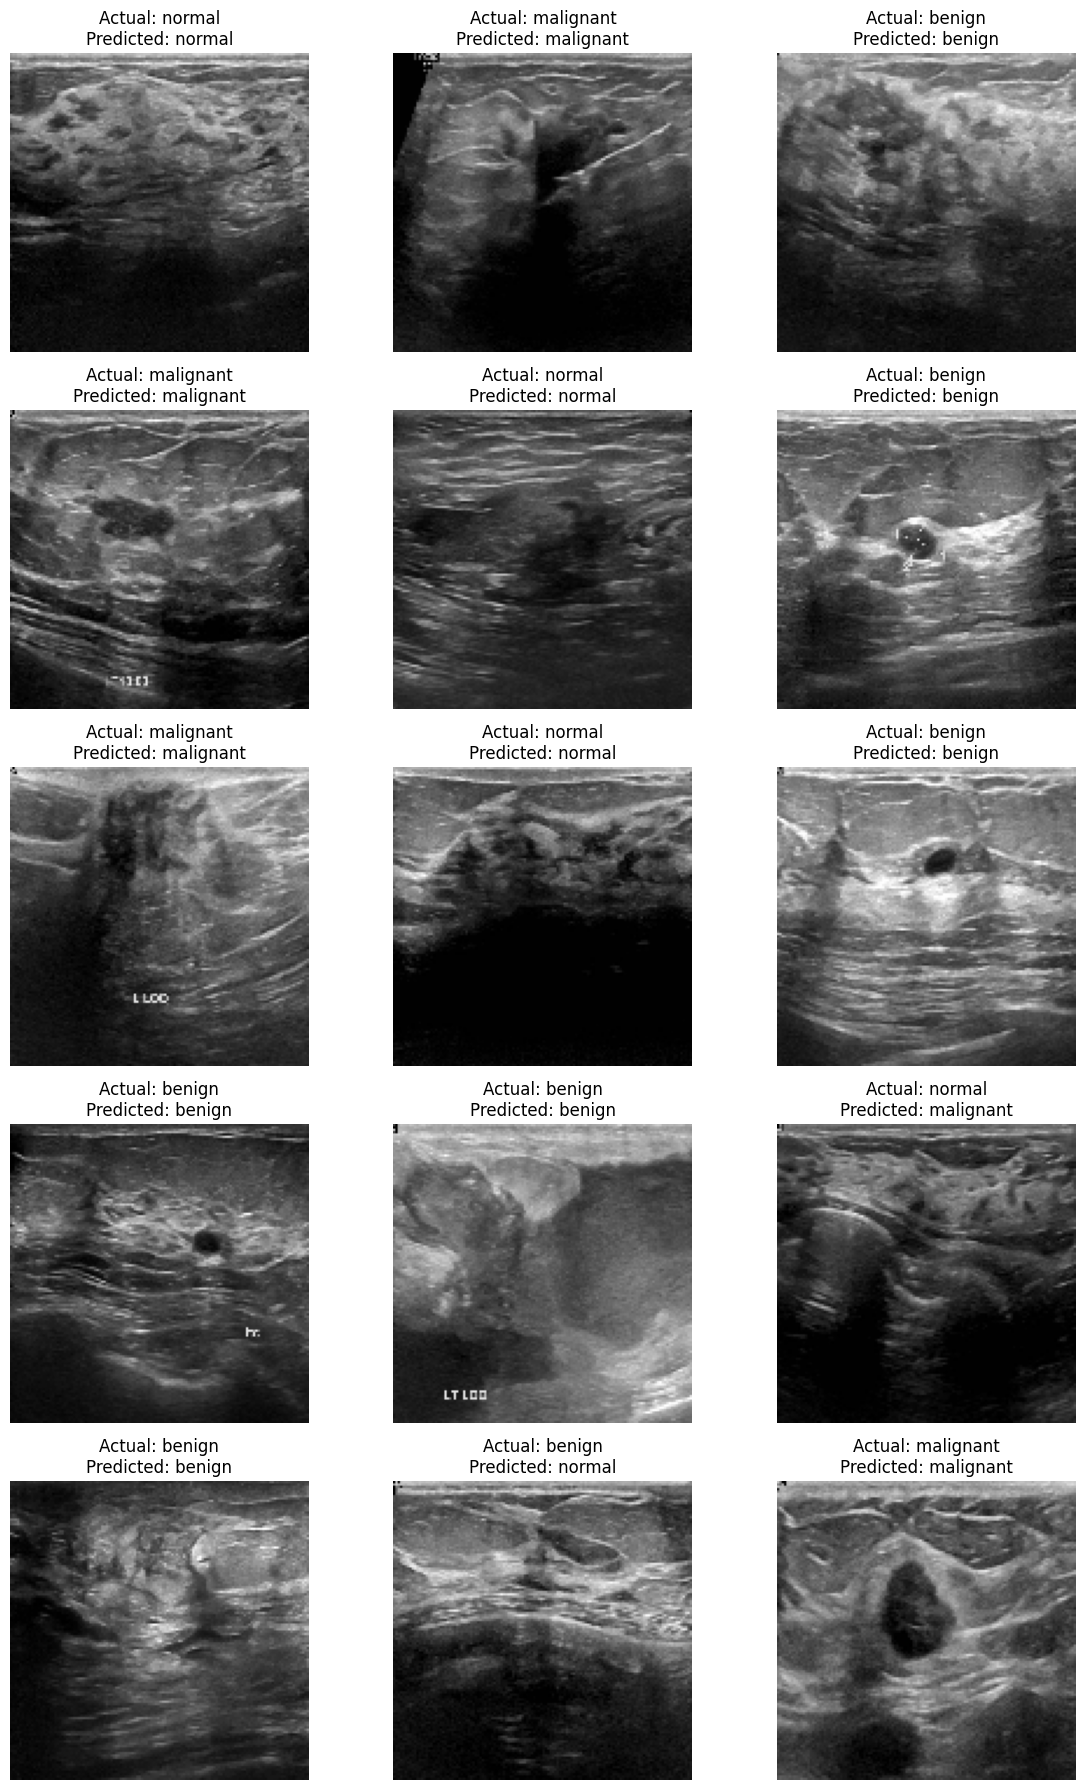

Predictions from Imbalanced Model
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


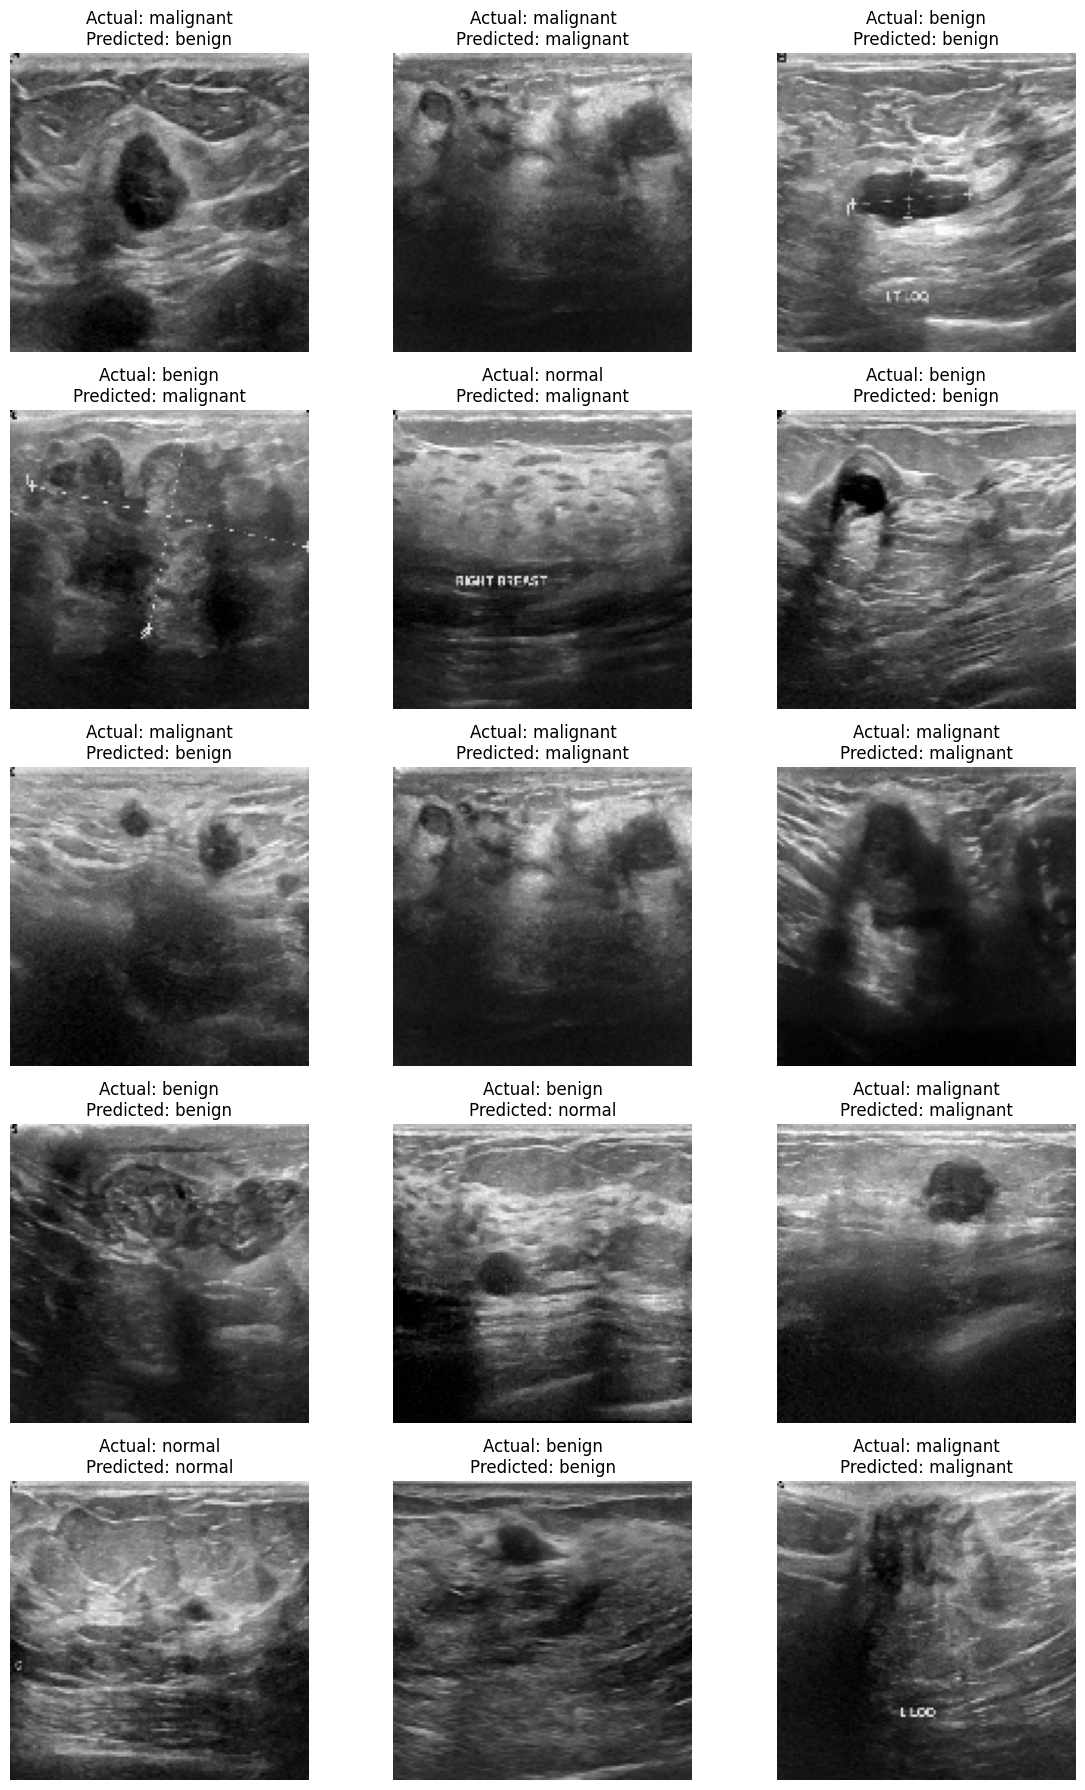

In [58]:
print("Predictions from SMOTE Balanced Model")
visualize_predictions(balanced_model, X_test, y_test, label_encoder)

print("Predictions from Imbalanced Model")
visualize_predictions(imbalanced_model, X_test, y_test, label_encoder)